In [7]:
# Pour la manipulation de tableaux
import numpy as np

# Imports nécessaires pour construire un modèle CNN avec l'API fonctionnelle de Keras
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model,load_model
from tensorflow.keras.layers import Dropout 
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Conv2D 
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications.densenet import preprocess_input
from sklearn.metrics import f1_score, accuracy_score, classification_report
import tensorflow as tf

# Pour encoder les labels
from tensorflow.keras.utils import to_categorical 

# Pour évaluer les performances 
from sklearn import metrics

# Pour visualiser les performances
import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns
import keras



In [ ]:
val_ds = image_dataset_from_directory(
    directory="../../../COVID-19_Radiography_Dataset_split/validation/",                                 
    image_size=(299, 299),
    batch_size = 32,
    labels="inferred",
    shuffle=False,
    color_mode='rgb'
)


# Pour avoir le nom des classes 
class_names_val = val_ds.class_names


# %%
test_ds = image_dataset_from_directory(
    directory="../../../COVID-19_Radiography_Dataset_split/test/",                                 
    image_size=(299,299),
    batch_size = 32,
    labels="inferred",
    shuffle=False,
    color_mode='rgb'
)

# Pour avoir le nom des classes 
class_names_test = test_ds.class_names






Found 2083 files belonging to 4 classes.
Found 2084 files belonging to 4 classes.


In [9]:
@keras.saving.register_keras_serializable()
class SparseF1Score(tf.keras.metrics.F1Score):
    """F1Score de Keras adaptée aux labels sparses (entiers) plutôt que one-hot."""
    def __init__(self, num_classes=4, **kwargs):
        super().__init__(**kwargs)
        self.num_classes_ = num_classes

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.one_hot(tf.cast(tf.reshape(y_true, [-1]), tf.int32), depth=self.num_classes_)
        return super().update_state(y_true, y_pred, sample_weight)
    


In [10]:

model_loaded = load_model('densenet.keras')
model_loaded.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 9, 9, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden_layer (Dense)      │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,696,398 (63.69 MB)

 Trainable params: 4,763,588 (18.17 MB)

 Non-trainable params: 2,405,632 (9.18 MB)

 Optimizer params: 9,527,178 (36.34 MB)

In [ ]:

# jeu de test
test_pred = model_loaded.predict(test_ds)
test_pred_class = test_pred.argmax(axis=1)
y_true_test_class = np.concatenate([labels for images,labels in test_ds] ,axis=0)

# jeu de validation
val_pred = model_loaded.predict(val_ds)
val_pred_class = val_pred.argmax(axis=1)
y_true_val_class = np.concatenate([labels for images,labels in val_ds] ,axis=0)



I0000 00:00:1784892483.139720   71503 service.cc:153] XLA service 0x7f63e00a0cd0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1784892483.139739   71503 service.cc:161]   StreamExecutor [0]: Host, Default Version (Driver: 0.0.0; Runtime: 0.0.0; Toolkit: 0.0.0; DNN: 0.0.0)
I0000 00:00:1784892483.219383   71503 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1784892484.344368   71503 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


66/66 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step
66/66 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step


              precision    recall  f1-score   support

           0       0.17      0.99      0.29       337
           1       1.00      0.00      0.01       599
           2       0.39      0.03      0.06      1014
           3       1.00      0.01      0.03       134

    accuracy                           0.18      2084
   macro avg       0.64      0.26      0.09      2084
weighted avg       0.57      0.18      0.08      2084



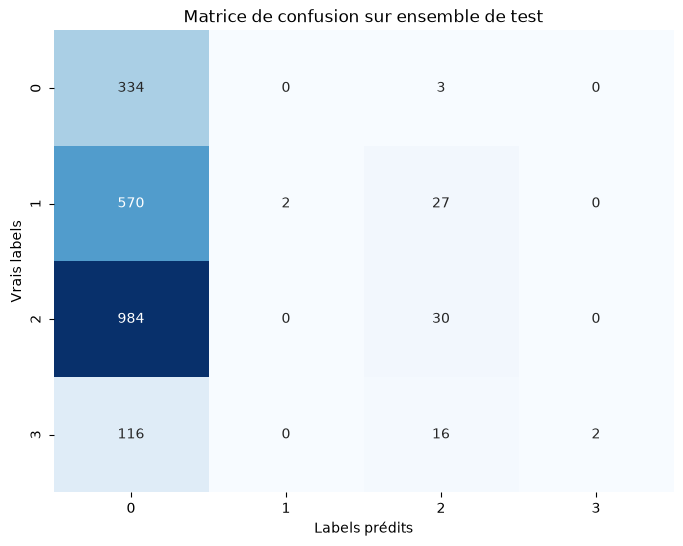

In [12]:
# Pour avoir le nom des classes (des poissons)

print(metrics.classification_report(y_true_test_class, test_pred_class))

# Calculer la matrice de confusion
cnf_matrix = metrics.confusion_matrix(y_true_test_class, test_pred_class)

# Tracer la heatmap de la matrice de confusion
plt.figure(figsize=(8, 6))

plt.title("Matrice de confusion sur ensemble de test")
sns.heatmap(cnf_matrix, cmap='Blues', annot=True, cbar=False, fmt="")
plt.ylabel('Vrais labels')
plt.xlabel('Labels prédits')
plt.show()


              precision    recall  f1-score   support

           0       0.17      0.99      0.28       338
           1       0.00      0.00      0.00       598
           2       0.56      0.03      0.07      1013
           3       1.00      0.04      0.07       134

    accuracy                           0.18      2083
   macro avg       0.43      0.27      0.11      2083
weighted avg       0.36      0.18      0.08      2083



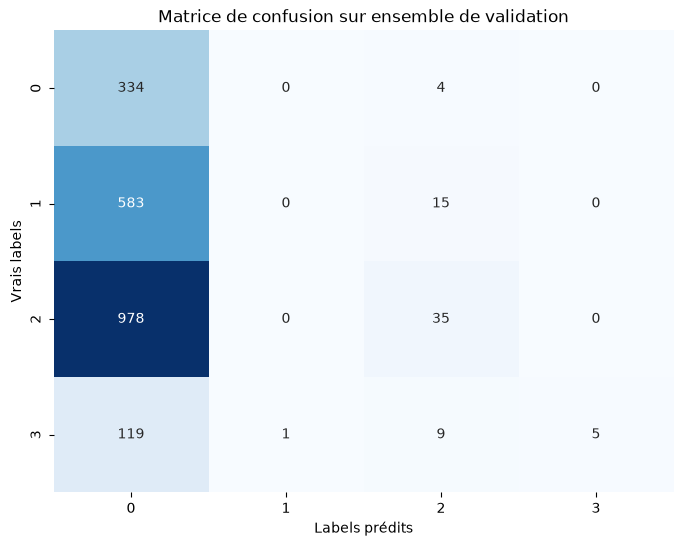

In [13]:
print(metrics.classification_report(y_true_val_class, val_pred_class))


# Calculer la matrice de confusion
cnf_matrix = metrics.confusion_matrix(y_true_val_class, val_pred_class)

# Tracer la heatmap de la matrice de confusion
plt.figure(figsize=(8, 6))

plt.title("Matrice de confusion sur ensemble de validation")
sns.heatmap(cnf_matrix, cmap='Blues', annot=True, cbar=False, fmt="")
plt.ylabel('Vrais labels')
plt.xlabel('Labels prédits')
plt.show()
